In [ ]:
%load_ext autoreload
%autoreload 2
import helpers
# from helpers import evaluate_forecast



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 6)


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [17]:
data_path = "../btc_data/BTCUSD_1m_Binance.csv"

btc_df = pd.read_csv(data_path, nrows=1)
display(btc_df.head())

btc_df = pd.read_csv(data_path, usecols=["Open time", "Close"])
display(btc_df.head())

# rename columns
btc_df.columns = ["timestamp", "close_price"]
display(btc_df.head())

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183,2017-08-17 04:00:59.999,7564.906851,3.0,0.075183,320.390851,0.0


,Open time,Close
0,2017-08-17 04:00:00,4261.48
1,2017-08-17 04:01:00,4261.48
2,2017-08-17 04:02:00,4280.56
3,2017-08-17 04:03:00,4261.48
4,2017-08-17 04:04:00,4261.48


,timestamp,close_price
0,2017-08-17 04:00:00,4261.48
1,2017-08-17 04:01:00,4261.48
2,2017-08-17 04:02:00,4280.56
3,2017-08-17 04:03:00,4261.48
4,2017-08-17 04:04:00,4261.48


In [18]:
btc_df["timestamp"] = pd.to_datetime(btc_df["timestamp"])
print(f"timestamp data type: {btc_df["timestamp"].dtype}")

# set timestamp as index
btc_df.set_index("timestamp", inplace=True)

# we sort index
btc_df = btc_df.sort_index()
display(btc_df.head())

timestamp data type: datetime64[us]


,close_price
timestamp,
2017-08-17 04:00:00,4261.48
2017-08-17 04:01:00,4261.48
2017-08-17 04:02:00,4280.56
2017-08-17 04:03:00,4261.48
2017-08-17 04:04:00,4261.48


In [19]:
# Resample the dataframe to a Daily frequency ('D'). 
btc_daily = btc_df.resample("D").mean()

# make index Day frequency
btc_df = btc_df.asfreq("D")

print("Aggregated Daily Data:")
display(btc_daily.head())

print(f"Count of missing values (BEFORE): {btc_daily["close_price"].isna().sum()}")

btc_daily["close_price"].dropna(inplace=True)

print(f"Count of missing values (AFTER): {btc_daily["close_price"].isna().sum()}")

Aggregated Daily Data:


,close_price
timestamp,
2017-08-17,4358.630667
2017-08-18,4230.951715
2017-08-19,4070.712250
2017-08-20,4123.014063
2017-08-21,4035.014465


Count of missing values (BEFORE): 0
Count of missing values (AFTER): 0


### Exploring Data

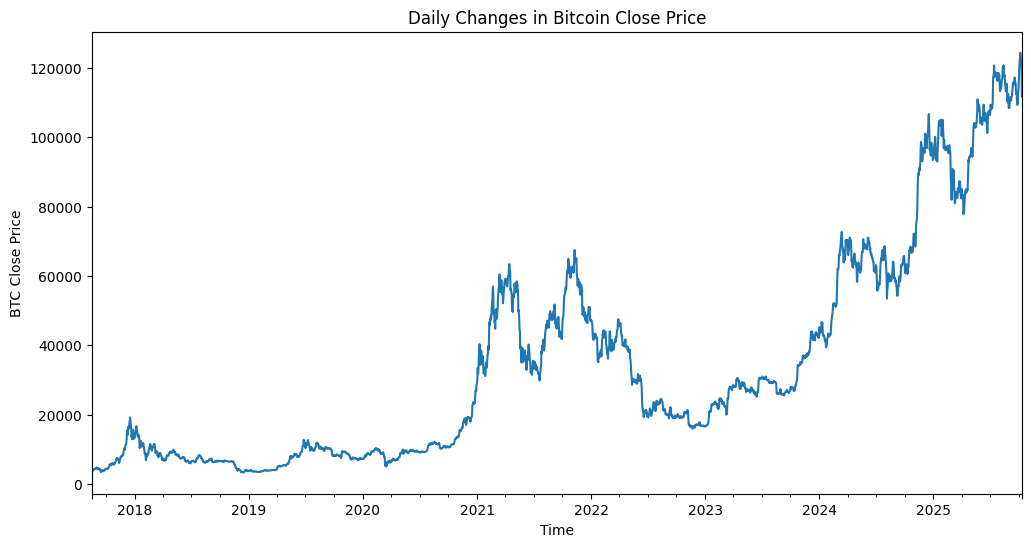

In [20]:
# plot price againest time
btc_daily["close_price"].plot()
plt.title("Daily Changes in Bitcoin Close Price")
plt.xlabel("Time")
plt.ylabel("BTC Close Price")
plt.show()

From the graph of the daily changes in Bitcoin’s closing price, we see an upward trend, as prices have started to increase over the past five years. Regarding patterns, fluctuations have become larger over time. In the earlier years (2018–2020), the changes were small, while in the later years (2024–2025), similar movements appear much bigger, indicating that the variability is not constant. From this plot, it is difficult to clearly identify repeating patterns. On the other hand, there are longer-term rises and falls around 2021 and late 2024, which are likely influenced by broader market or economic conditions.

From this point, we can analyze the series components to determine the seasonality and trend behavior over time.

## Time Series Decomposition

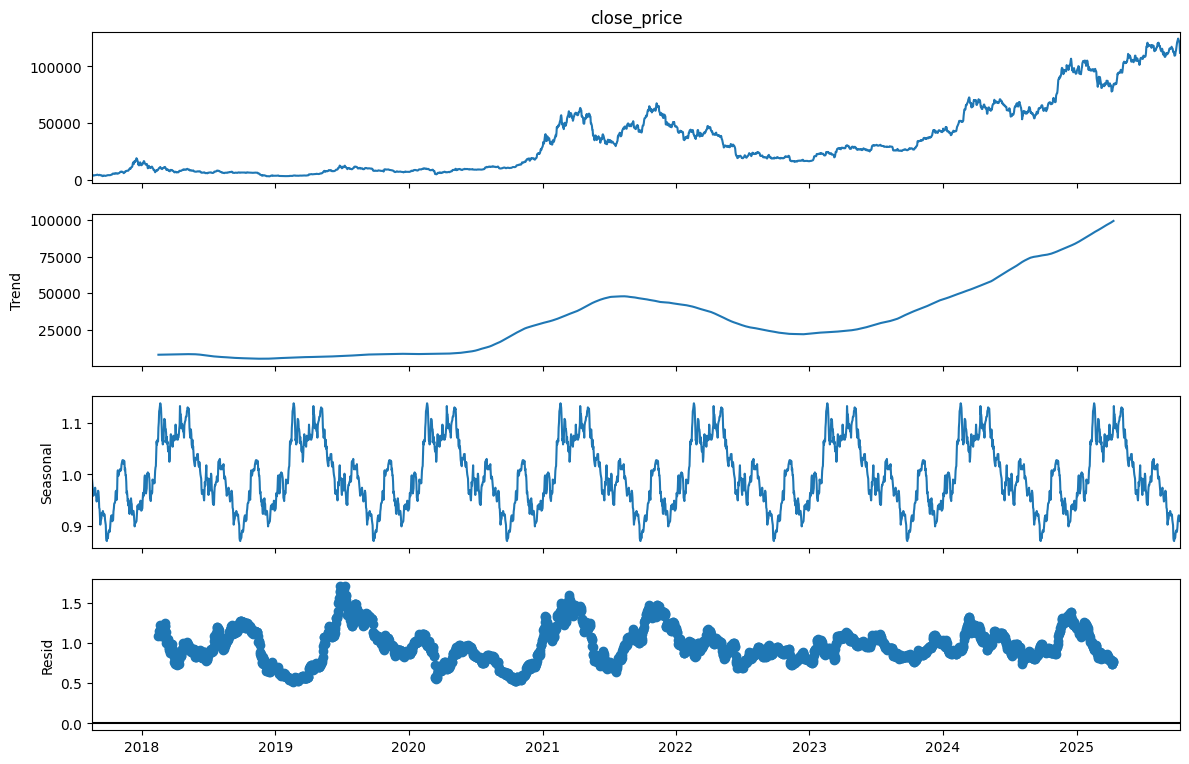

In [21]:
decomposition = seasonal_decompose(btc_daily["close_price"], model="multiplicative", period=365)

# Plot the decomposition.
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

A trend is not always a straight line. In this graph as in (2018–2020) The trend is almost flat, which indicates a period of price stability where the long-term value was not growing significantly while in (2021 & 2024-) the trend line curves upward sharply, in (2022-2023) the trend line actually goes down where the long-term value was decreasing

### Testing Stationary

In [25]:
is_stationary, p_value = helpers.adf_test(btc_daily["close_price"]) 

ADF Statistic: 0.2756666596150291

ADF p-value: 0.9762001267679113

Critical Value:
1%: -3.432554433400684
5%: -2.862513974608172
10%: -2.5672884729234764

The series is non-stationary


Since the H0 (null-hypothesis) in ADF test is that the series is non-stationary and H1 (Alternative hypothesis) is that the series is Stationary, we set the significance level to compare the p-value with (0.05) so the Series is non-stationary since the p-value > 0.05 and the model fail to reject the null-hypothesis.

So we need to make data **Stationary** by using Differencing and Logarithm to remove the versatility in the data's seasonality.

In [34]:
btc_diff = btc_daily.copy()

In [35]:
d = 0
series = btc_diff["close_price"].copy()

for _ in range(2):
    series = series.dropna()

    is_stationary, _ = helpers.adf_test(series)

    if is_stationary:
        break

    series = series.diff()
    d += 1

print(d)

ADF Statistic: 0.2756666596150291

ADF p-value: 0.9762001267679113

Critical Value:
1%: -3.432554433400684
5%: -2.862513974608172
10%: -2.5672884729234764

The series is non-stationary
ADF Statistic: -19.551423356521532

ADF p-value: 0.0

Critical Value:
1%: -3.432554433400684
5%: -2.862513974608172
10%: -2.5672884729234764

The series is stationary.
1


So we only need to apply differencing to the series only one time to be Stationary, we will keep track of variable `d` so that we know how many times we need to apply differencing on the data series.

but first we will apply Differencing on Log of Series.

In [37]:
btc_diff = btc_daily.copy()

btc_diff["close_price_log"] = np.log(btc_daily["close_price"])

d = 0
series = btc_diff["close_price_log"].copy()

for _ in range(2):
    series = series.dropna()

    is_stationary, _ = helpers.adf_test(series)

    if is_stationary:
        break

    series = series.diff()
    d += 1

print(d)

ADF Statistic: -1.0464409648673085

ADF p-value: 0.7359516320139596

Critical Value:
1%: -3.432549243758671
5%: -2.8625116825389747
10%: -2.5672872526493307

The series is non-stationary
ADF Statistic: -43.318774241526086

ADF p-value: 0.0

Critical Value:
1%: -3.432549243758671
5%: -2.8625116825389747
10%: -2.5672872526493307

The series is stationary.
1


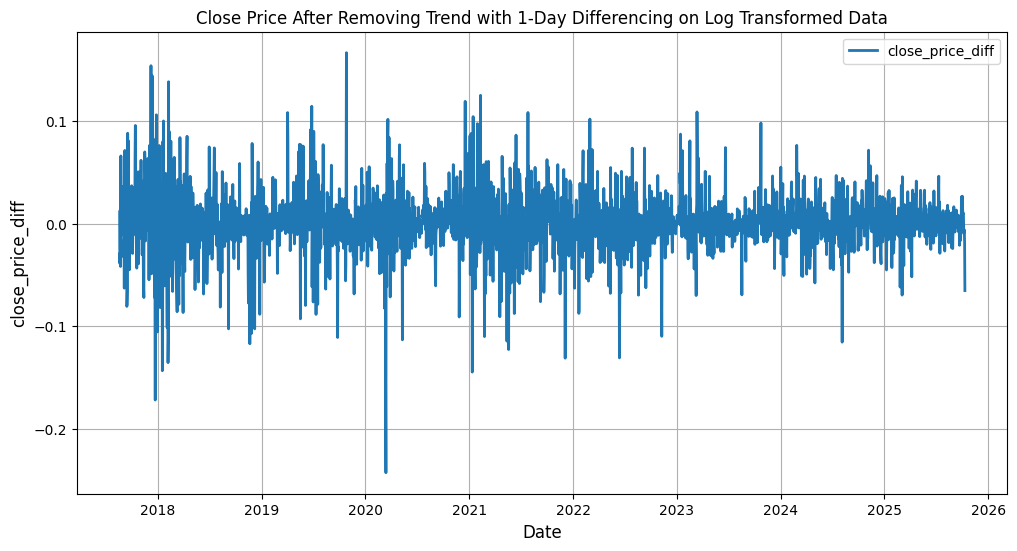

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(series.index, series, label='close_price_diff', linewidth=2)
plt.title(f'Close Price After Removing Trend with {d}-Day Differencing on Log Transformed Data')
plt.xlabel('Date', fontsize=12)
plt.ylabel('close_price_diff', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

Now we will plot Autocorrelation and Partial Autocorrelation to determine the AR (p) and MA (q) Parameters for ARIMA Model.

In [47]:
btc_daily["close_price_log_diff"] = series.dropna()

btc_daily.dropna(inplace=True)

btc_daily.head()

,close_price,close_price_log,close_price_log_diff
timestamp,,,
2017-08-18,4230.951715,8.350182,-0.029731
2017-08-19,4070.712250,8.311573,-0.038609
2017-08-20,4123.014063,8.324340,0.012766
2017-08-21,4035.014465,8.302765,-0.021575
2017-08-22,3869.847722,8.260970,-0.041795


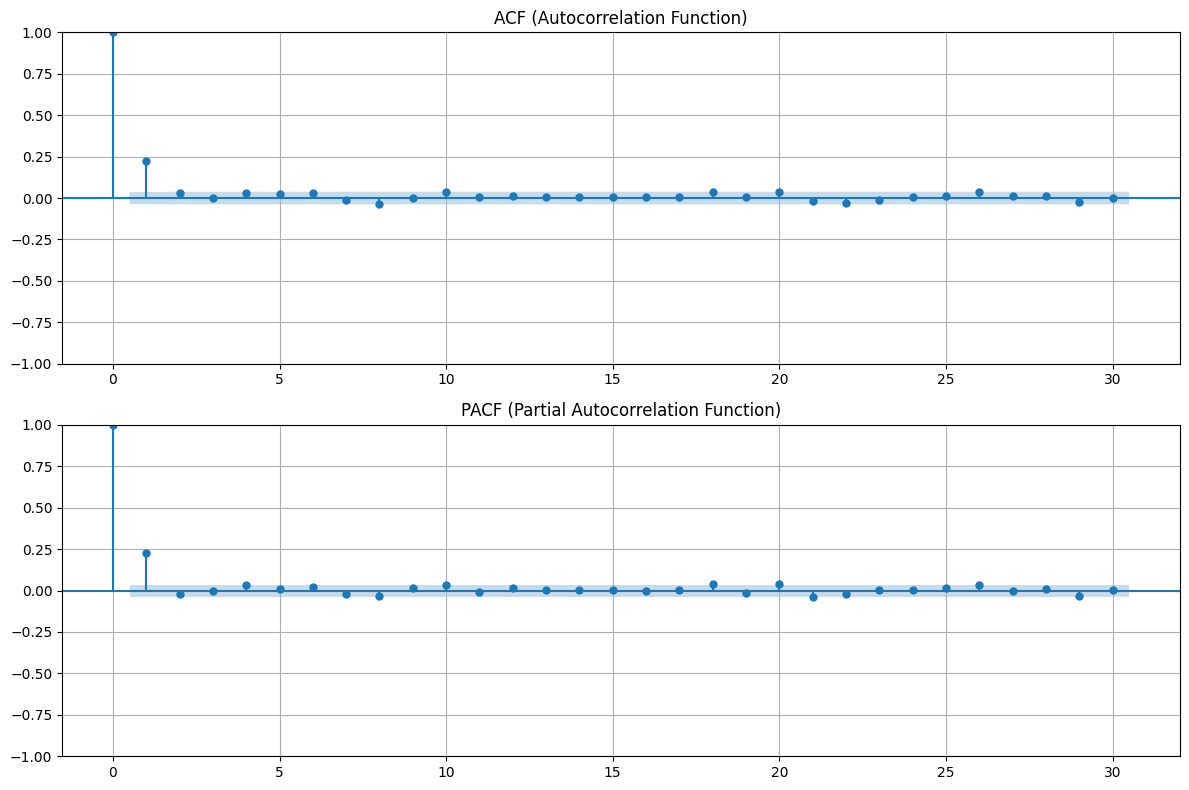

In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(btc_daily["close_price_log_diff"].dropna(), lags=30, ax=ax1)
ax1.set_title("ACF (Autocorrelation Function)")
ax1.grid(True)

plot_pacf(btc_daily["close_price_log_diff"].dropna(), lags=30, ax=ax2)
ax2.set_title("PACF (Partial Autocorrelation Function)")
ax2.grid(True)

plt.tight_layout()
plt.show()

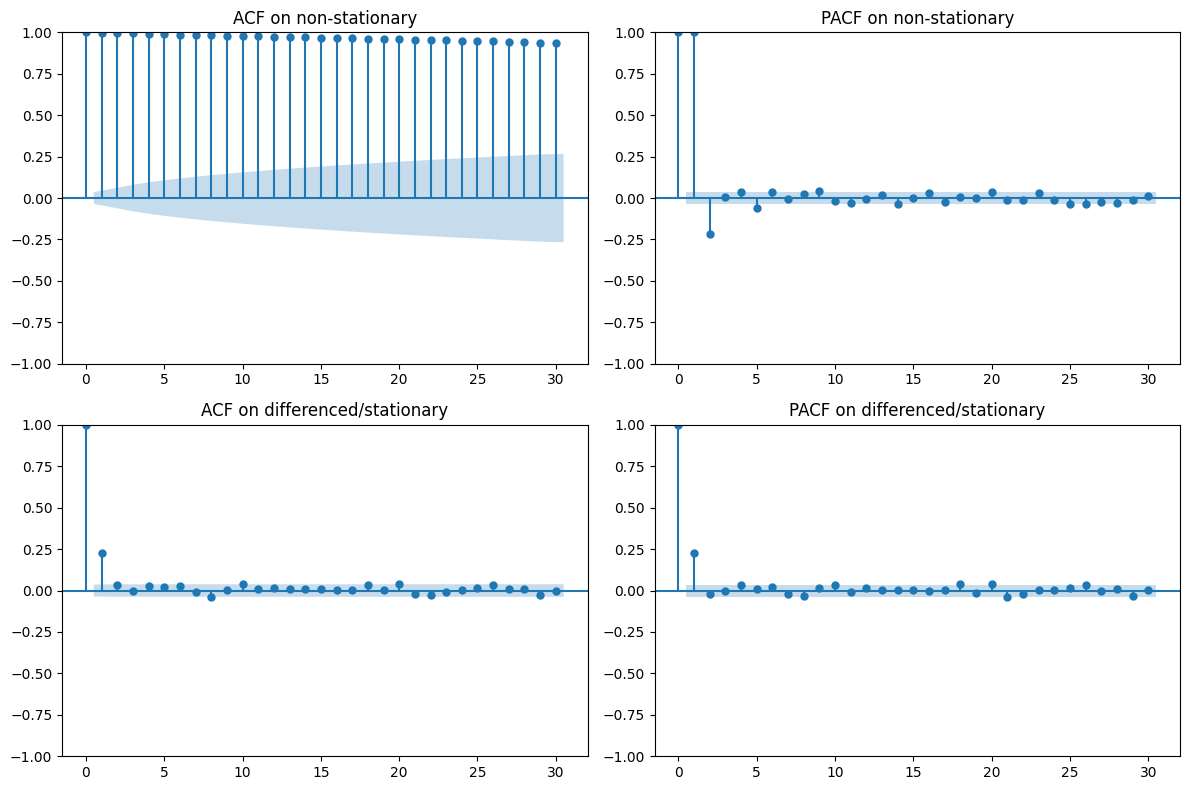

In [49]:
f, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

plot_acf(btc_daily['close_price'], lags=30, ax=ax[0, 0], title='ACF on non-stationary')
plot_pacf(btc_daily['close_price'], lags=30, ax=ax[0, 1], method='ols', title='PACF on non-stationary')

plot_acf(btc_daily['close_price_log_diff'], lags=30, ax=ax[1, 0], title='ACF on differenced/stationary')
plot_pacf(btc_daily['close_price_log_diff'], lags=30, ax=ax[1, 1], method='ols', title='PACF on differenced/stationary')

plt.tight_layout()
plt.show()

Observations: from the plot we have single non-zero significant autocorrelation at lag=1 in both PCAF and ACF (p=1, q=0) at differenced data (d=1) but since there is no decaying in PACF then there might be no previous error effect on the future values hence (q=0) so the data is random and the patterns are unpredectable. so the series has short memory as the values depends on the previos few values about (1, 2, 3) value before.
Also from modeling trend, and seasonality within original data we see there is an obvious learnable pattern but after differencing the data the pattern disappeared.

**But for experimenting we will go with (p=2, d=1, q=2) as we will consider that the next value will depend on the prevoius 2 values, and if we will work with seasonal model we will consider the monthly seasonality (m=30) and the seasonal AR level (P=1) and MA level (Q=1).**

In [52]:
# prepare train/test set
train = btc_daily.iloc[:-60]
test = btc_daily.iloc[-60:]

print("Train Set: ", len(train))
print("Test Set: ", len(test))

display(train.tail(5))
display(test.head(5))

Train Set:  2917
Test Set:  60


,close_price,close_price_log,close_price_log_diff
timestamp,,,
2025-08-08,116683.521389,11.667221,0.006932
2025-08-09,116781.779319,11.668062,0.000842
2025-08-10,118227.246674,11.680364,0.012302
2025-08-11,120374.273583,11.698361,0.017997
2025-08-12,119211.152521,11.688652,-0.009710


,close_price,close_price_log,close_price_log_diff
timestamp,,,
2025-08-13,120807.372903,11.701953,0.013301
2025-08-14,120382.384639,11.698428,-0.003524
2025-08-15,118175.397826,11.679925,-0.018503
2025-08-16,117596.614861,11.675016,-0.004910
2025-08-17,117906.193674,11.677645,0.002629


In [68]:
# Parameters
p, d, q = 2, d, 2  # Non-seasonal ARIMA parameters
P, D, Q, m = 0, 0, 0, 30


model = ARIMA(train['close_price_log_diff'], order=(p, d, q), seasonal_order=(P, D, Q, m)) 

fitted_model = model.fit()

# Print the model summary.
print(fitted_model.summary())

                                SARIMAX Results                                 
Dep. Variable:     close_price_log_diff   No. Observations:                 2917
Model:                   ARIMA(2, 1, 2)   Log Likelihood                6202.007
Date:                  Tue, 21 Apr 2026   AIC                         -12394.013
Time:                          01:08:57   BIC                         -12364.123
Sample:                      08-18-2017   HQIC                        -12383.246
                           - 08-12-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7557      0.017    -43.554      0.000      -0.790      -0.722
ar.L2          0.2283      0.011     20.497      0.000       0.206       0.250
ma.L1         -0.0198      0.024    

After we have tried different parameters for ARIMA we decided to apply **AutoARIMA**, So that finding the best base model parameters can be found easily.

In [80]:
results_df = helpers.compare_seasonality(
    train,
    test,
    target_col="close_price_log_diff",
    season_lengths=[1, 7, 14, 30]
)

print(results_df)

Order: (1, 0, 0)
Seasonal Order: (0, 0, 0, 0)
✅ Done m=1
Order: (1, 0, 0)
Seasonal Order: (0, 0, 0, 7)
✅ Done m=7
Order: (1, 0, 0)
Seasonal Order: (0, 0, 0, 14)
✅ Done m=14
Order: (1, 0, 0)
Seasonal Order: (0, 0, 0, 30)
✅ Done m=30
   season_length       MAE      RMSE      MAPE      order seasonal_order
0              1  0.010696  0.014553  1.017706  (1, 0, 0)   (0, 0, 0, 0)
1              7  0.010696  0.014553  1.017706  (1, 0, 0)   (0, 0, 0, 7)
2             14  0.010696  0.014553  1.017706  (1, 0, 0)  (0, 0, 0, 14)
3             30  0.010696  0.014553  1.017706  (1, 0, 0)  (0, 0, 0, 30)


The objective of this experiment was to evaluate the effect of different seasonal configurations on the performance of an AutoARIMA model applied to the log-differenced Bitcoin closing price. 

We tested four seasonal periods (m = 1, 7, 14, and 30) to determine whether introducing seasonality could improve forecasting accuracy. The model consistently converged to the same structure across all experiments, resulting in an ARIMA(1,0,0) configuration with no active seasonal components, regardless of the seasonal period provided. 

As a result, all configurations produced identical performance metrics, with MAE = 0.010696, RMSE = 0.014553, and MAPE = 1.017706. This indicates that the seasonal parameter had no influence on the model’s behavior and that the underlying data does not exhibit meaningful seasonal patterns in its log-differenced form. 

Instead, the model primarily captures short-term autoregressive dependencies, suggesting that the series is largely stochastic and weakly seasonal at best. Based on these findings, seasonality does not contribute to improving predictive performance for this dataset, and the ARIMA model effectively reduces to a simple AR(1) process.

Order: (1, 0, 0)
Seasonal Order: (0, 0, 0, 7)


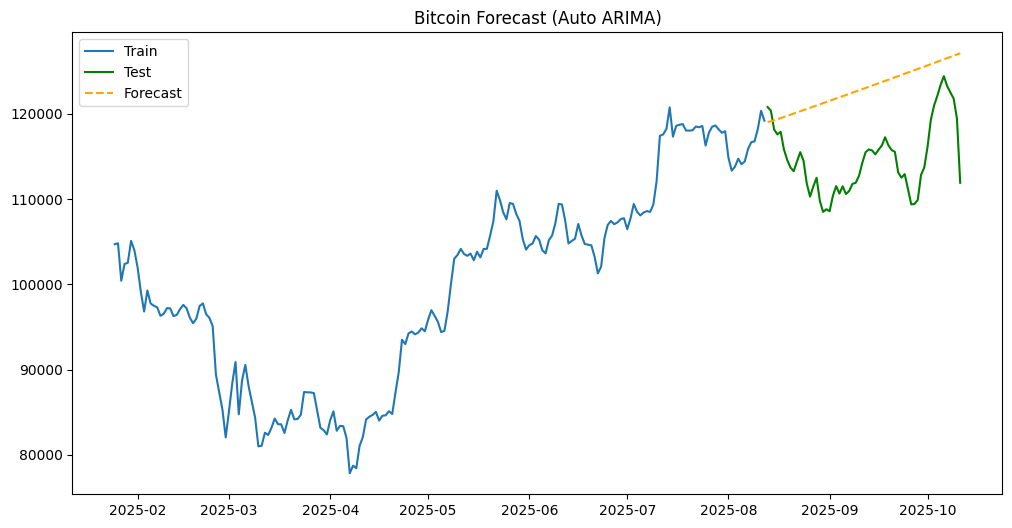

In [87]:
result = helpers.run_autoarima_pipeline(
    train,
    test,
    target_col="close_price_log_diff",
    season_length=7
)

price_forecast = helpers.reconstruct_price_from_diff_log(
    result["forecast"],
    last_log_price=train["close_price_log"].iloc[-1]
)

helpers.plot_forecast(
    train["close_price"],
    test["close_price"],
    price_forecast,
    title="Bitcoin Forecast (Auto ARIMA)"
)

Looking at the metrics and the plot, the main issue is quite clear. Across all season lengths (1, 7, 14, 30), the model produces identical results, which shows that the seasonal parameter has no real impact. AutoARIMA consistently converges to an ARIMA(1,0,0) model with no seasonal components, meaning it is ignoring seasonality completely and simplifying the problem into a basic AR process.

Because of this, the model falls into a mean-reversion behavior, producing a smooth and overly stable forecast that does not reflect the real volatility in Bitcoin. Although the MAE, RMSE, and MAPE look relatively low, this is mainly due to working in log space where values are compressed, so the metrics can be misleading. The MAPE of around 1% suggests only small average deviation, but it does not capture the model’s inability to follow actual market movements.

From the plot, it is clear that while the test data shows strong fluctuations, the forecast remains smooth and almost linear, failing to capture the sharp ups and downs. Overall, the model is underfitting the data and reducing everything to a simple AR(1) structure, which results in a stable but unrealistic prediction of Bitcoin’s behavior.